1. Bibliothèques importées avec succès.

2. Données chargées. Taille du dataset : (442, 11)
   Variables explicatives : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
   Type de problème       : Régression (prédiction de la progression du diabète)

3. Introduction artificielle de valeurs manquantes (NaN)...
   Nombre total de valeurs manquantes générées : 220

4. Nettoyage des données...
   Imputation terminée (les NaN ont été remplacés par la moyenne).
   Valeurs manquantes restantes : 0

5. Analyse Exploratoire (EDA)...
   Statistiques descriptives (toutes les features) :
              age         sex         bmi          bp          s1          s2  \
count  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000   
mean    -0.000195   -0.000612   -0.000547   -0.000282   -0.000865   -0.000742   
std      0.046045    0.046377    0.045752    0.046734    0.045354    0.045782   
min     -0.107226   -0.044642   -0.089197   -0.112399   -0.108893   -0.115613 

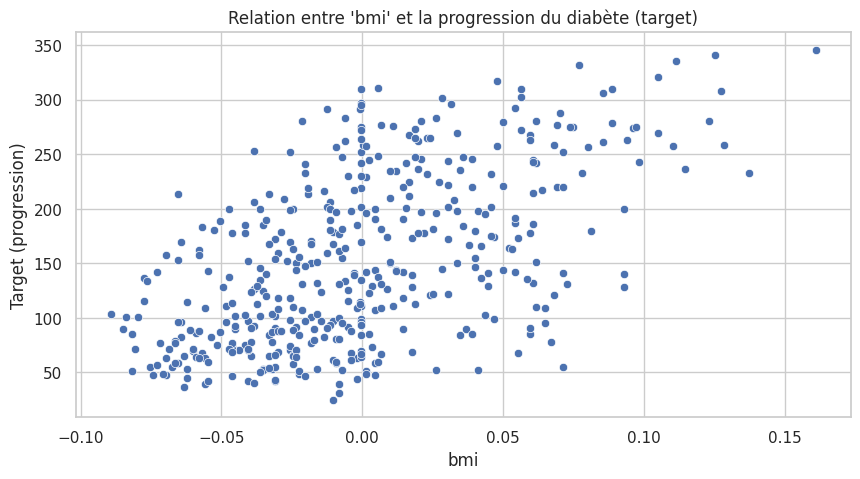

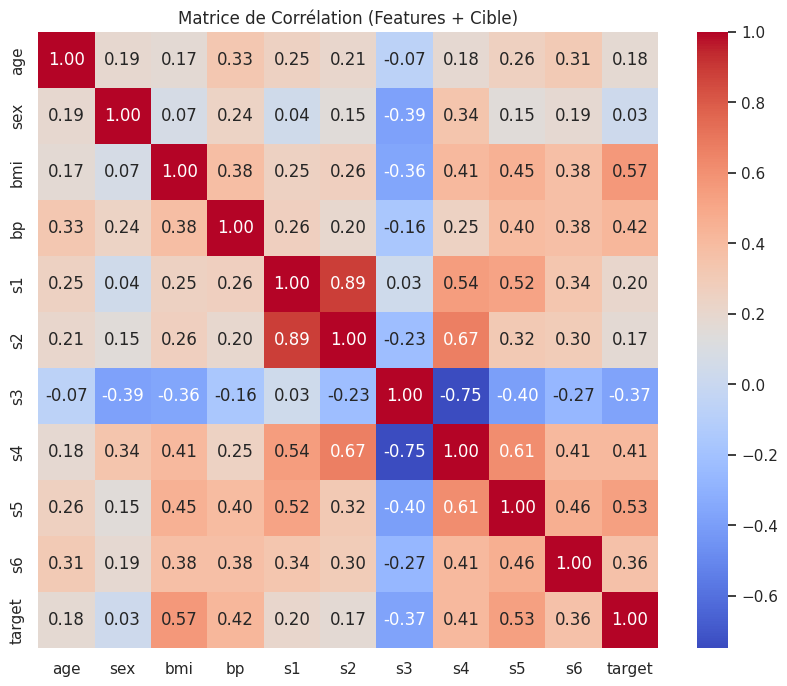


6. Séparation effectuée :
   Entraînement : 353 échantillons
   Test         : 89 échantillons

7. Entraînement du modèle (Random Forest Regressor)...
   Modèle entraîné avec succès.

8. Évaluation des performances (Régression)...
   >>> MSE  : 4888.99
   >>> RMSE : 69.92
   >>> MAE  : 54.03
   >>> R²   : 0.077


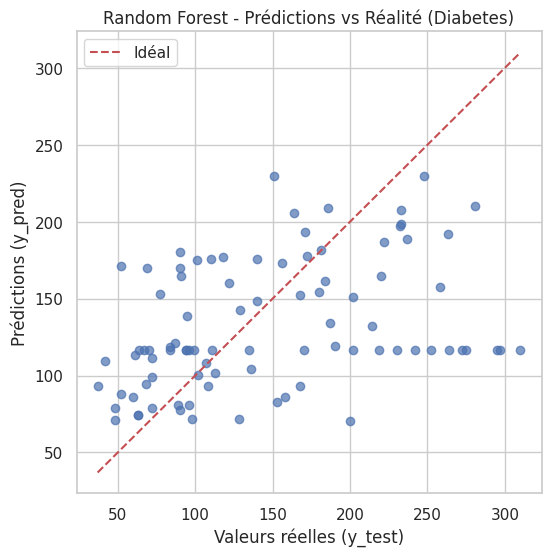


--- FIN DU SCRIPT ---


In [2]:
# ==============================================================================
# COURS DATA SCIENCE : CYCLE DE VIE COMPLET (RÉGRESSION SUR DIABETES)
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. IMPORTATION DES BIBLIOTHÈQUES
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modules Scikit-Learn spécifiques
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuration pour des graphiques plus esthétiques
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')  # Pour garder la sortie propre

print("1. Bibliothèques importées avec succès.\n")

# ------------------------------------------------------------------------------
# 2. CHARGEMENT DES DONNÉES
# ------------------------------------------------------------------------------
# Chargement du dataset Diabetes depuis Scikit-Learn
# Dataset = 442 patients, 10 variables continues, cible = progression de la maladie (régression)
data = load_diabetes(as_frame=True)

# Création du DataFrame Pandas
df = data.frame.copy()   # contient déjà les features et la cible
# Selon la version de sklearn, la colonne cible s'appelle 'target'
df.rename(columns={'target': 'target'}, inplace=True)

print(f"2. Données chargées. Taille du dataset : {df.shape}")
print("   Variables explicatives :", list(data.feature_names))
print("   Type de problème       : Régression (prédiction de la progression du diabète)\n")

# ------------------------------------------------------------------------------
# 3. SIMULATION DE \"DONNÉES SALES\" (Pour l'exercice)
# ------------------------------------------------------------------------------
# Dans la vraie vie, les données sont rarement parfaites.
# Nous allons introduire artificiellement des valeurs manquantes (NaN) dans 5% des données.
print("3. Introduction artificielle de valeurs manquantes (NaN)...")

np.random.seed(42)  # Pour la reproductibilité

# On applique des NaN partout sauf sur la colonne 'target'
features_columns = [c for c in df.columns if c != "target"]
df_dirty = df.copy()
for col in features_columns:
    df_dirty.loc[df_dirty.sample(frac=0.05, random_state=42).index, col] = np.nan

print(f"   Nombre total de valeurs manquantes générées : {df_dirty.isnull().sum().sum()}\n")

# ------------------------------------------------------------------------------
# 4. NETTOYAGE ET PRÉPARATION (Data Wrangling)
# ------------------------------------------------------------------------------
print("4. Nettoyage des données...")

# Séparation Features (X) et Target (y) AVANT le nettoyage pour éviter les fuites de données
X = df_dirty.drop('target', axis=1)
y = df_dirty['target']

# Imputation : Remplacer les NaN par la MOYENNE de la colonne
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# On remet sous forme de DataFrame pour garder les noms de colonnes (plus propre)
X_clean = pd.DataFrame(X_imputed, columns=X.columns)

print("   Imputation terminée (les NaN ont été remplacés par la moyenne).")
print(f"   Valeurs manquantes restantes : {X_clean.isnull().sum().sum()}\n")

# ------------------------------------------------------------------------------
# 5. ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
# ------------------------------------------------------------------------------
print("5. Analyse Exploratoire (EDA)...")

# A. Aperçu statistique
print("   Statistiques descriptives (toutes les features) :")
print(X_clean.describe())

# B. Visualisation 1 : Relation entre une feature clé et la cible (ex. BMI vs target)
plt.figure(figsize=(10, 5))
feature_to_plot = 'bmi'
sns.scatterplot(x=X_clean[feature_to_plot], y=y)
plt.title(f"Relation entre '{feature_to_plot}' et la progression du diabète (target)")
plt.xlabel(feature_to_plot)
plt.ylabel("Target (progression)")
plt.show()

# C. Visualisation 2 : Heatmap de corrélation (features + cible)
plt.figure(figsize=(10, 8))
correlation_matrix = pd.concat([X_clean, y], axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation (Features + Cible)")
plt.show()

# ------------------------------------------------------------------------------
# 6. SÉPARATION DES DONNÉES (Train / Test Split)
# ------------------------------------------------------------------------------
# On garde 20% des données pour le test final
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)

print("\n6. Séparation effectuée :")
print(f"   Entraînement : {X_train.shape[0]} échantillons")
print(f"   Test         : {X_test.shape[0]} échantillons\n")

# ------------------------------------------------------------------------------
# 7. MODÉLISATION (Machine Learning - RÉGRESSION)
# ------------------------------------------------------------------------------
print("7. Entraînement du modèle (Random Forest Regressor)...")

# Initialisation du modèle de régression
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Entraînement sur les données d'entraînement uniquement
model.fit(X_train, y_train)
print("   Modèle entraîné avec succès.\n")

# ------------------------------------------------------------------------------
# 8. ÉVALUATION ET PERFORMANCE
# ------------------------------------------------------------------------------
print("8. Évaluation des performances (Régression)...")

# Prédictions sur le jeu de test (données jamais vues par le modèle)
y_pred = model.predict(X_test)

# A. Métriques de régression
from math import sqrt

mse = mean_squared_error(y_test, y_pred)
rmse = sqrt(mse)              # au lieu de squared=False
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"   >>> MSE  : {mse:.2f}")
print(f"   >>> RMSE : {rmse:.2f}")
print(f"   >>> MAE  : {mae:.2f}")
print(f"   >>> R²   : {r2:.3f}")

# B. Visualisation : prédictions vs valeurs réelles
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label="Idéal")
plt.xlabel("Valeurs réelles (y_test)")
plt.ylabel("Prédictions (y_pred)")
plt.title("Random Forest - Prédictions vs Réalité (Diabetes)")
plt.legend()
plt.show()

print("\n--- FIN DU SCRIPT ---")
